# **Symtom Prediction Model**

**Importing Packages**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Importing Dataset**

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("niyarrbarman/symptom2disease")

path = os.path.join(path, os.listdir(path)[0])
print(path)

100%|██████████| 43.6k/43.6k [00:00<00:00, 56.1MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/niyarrbarman/symptom2disease/versions/1/Symptom2Disease.csv


In [3]:
df = pd.read_csv(path)
df

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."
...,...,...,...
1195,295,diabetes,I'm shaking and trembling all over. I've lost ...
1196,296,diabetes,"Particularly in the crevices of my skin, I hav..."
1197,297,diabetes,I regularly experience these intense urges and...
1198,298,diabetes,"I have trouble breathing, especially outside. ..."


**Analysing the dataset**

In [4]:
print(df.columns)

Index(['Unnamed: 0', 'label', 'text'], dtype='object')


In [5]:
# Checking null values

df.isna().sum()

,0
Unnamed: 0,0
label,0
text,0


In [6]:
print('Shape : ', df.shape)
print('Unnamed: 0 no_of_values : ',len(df['Unnamed: 0'].unique()))
print("Unique values of 'Unnamed: 0' : ", df['Unnamed: 0'].unique())

Shape :  (1200, 3)
Unnamed: 0 no_of_values :  300
Unique values of 'Unnamed: 0' :  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 

In [7]:
# Removing Unwanted columns
df = df.drop(columns=['Unnamed: 0'], axis=1)

In [8]:
#Analysing Target variables
print('Total Target Diseases Count : ',len(df['label'].unique()))

Total Target Diseases Count :  24


In [9]:
print(df['label'].value_counts())

label
Psoriasis                          50
Varicose Veins                     50
Typhoid                            50
Chicken pox                        50
Impetigo                           50
Dengue                             50
Fungal infection                   50
Common Cold                        50
Pneumonia                          50
Dimorphic Hemorrhoids              50
Arthritis                          50
Acne                               50
Bronchial Asthma                   50
Hypertension                       50
Migraine                           50
Cervical spondylosis               50
Jaundice                           50
Malaria                            50
urinary tract infection            50
allergy                            50
gastroesophageal reflux disease    50
drug reaction                      50
peptic ulcer disease               50
diabetes                           50
Name: count, dtype: int64


In [10]:
target_cols = df['label'].unique()
print(target_cols)


['Psoriasis' 'Varicose Veins' 'Typhoid' 'Chicken pox' 'Impetigo' 'Dengue'
 'Fungal infection' 'Common Cold' 'Pneumonia' 'Dimorphic Hemorrhoids'
 'Arthritis' 'Acne' 'Bronchial Asthma' 'Hypertension' 'Migraine'
 'Cervical spondylosis' 'Jaundice' 'Malaria' 'urinary tract infection'
 'allergy' 'gastroesophageal reflux disease' 'drug reaction'
 'peptic ulcer disease' 'diabetes']


In [11]:
# Target Labeling
df['label'] = df['label'].apply(lambda x: np.where(target_cols == x)[0][0])

In [12]:
# Stemming the text column
port_stem = PorterStemmer()
def stemming(content):
  stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if word not in stop_words]
  stemmed_content = ' '.join(stemmed_content)
  return stemmed_content

df['text'] = df['text'].apply(stemming)

<Axes: xlabel='label', ylabel='count'>

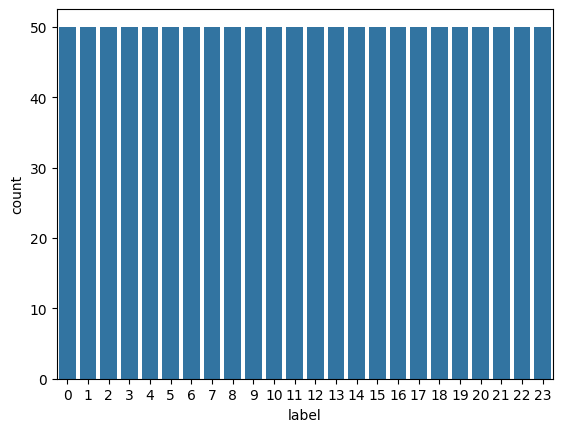

In [18]:
sns.countplot(x='label', data=df)

/tmp/ipykernel_2435/1235334074.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['label'], kde=True)


<Axes: ylabel='Density'>

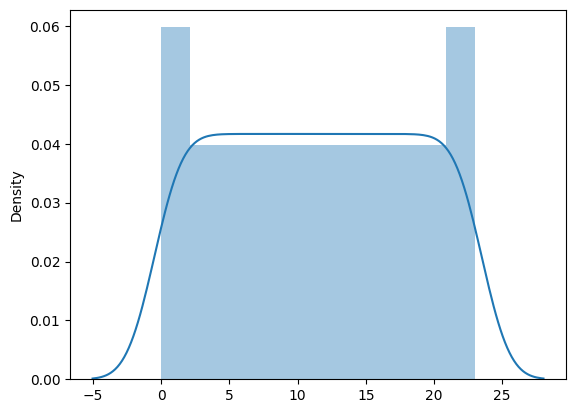

In [23]:
sns.distplot(x=df['label'], kde=True)

In [13]:
X = df['text']
Y = df['label']

In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, stratify=Y, random_state=2)

In [15]:
text_vec = TfidfVectorizer()
X_train_vec = text_vec.fit_transform(X_train)
X_test_vec = text_vec.transform(X_test)

In [16]:
symptom_model = LogisticRegression()
symptom_model.fit(X_train_vec, Y_train)
X_train_vec_pred = symptom_model.predict(X_train_vec)
X_test_vec_pred = symptom_model.predict(X_test_vec)
print('Training Accuracy : ', accuracy_score(X_train_vec_pred, Y_train))
print('Testing Accuracy : ', accuracy_score(X_test_vec_pred, Y_test))

Training Accuracy :  0.9958333333333333
Testing Accuracy :  0.9791666666666666


In [17]:
user_disease_input = input('Enter your symptoms : ')
user_disease_input = stemming(user_disease_input)
user_disease_input = [user_disease_input]
user_disease_input = text_vec.transform(user_disease_input)
user_disease_input_pred = symptom_model.predict(user_disease_input)
print(target_cols[user_disease_input_pred[0]])

Enter your symptoms : i have severe headache and my vision is blurry 
Migraine
